In [51]:
import pandas as pd
df = pd.read_csv("Resume.csv")
df.head(5)
df.info()
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
Duplicate rows: 0


In [52]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.isnull().sum())

(2484, 4)
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [53]:
df = df[['Resume_str','Category']]
df.dropna(inplace=True)
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [54]:
print(df["Category"].value_counts())

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [55]:
import pandas as pd
df = pd.read_csv("Resume.csv")
df = df[['Resume_str', 'Category']]
df.dropna(inplace=True)
x = df["Resume_str"]
y = df["Category"]

SPLITING DATASET

In [56]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 1987
Testing samples: 497


CLEANING

In [57]:
import re
def clean(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t
x_train = x_train.apply(clean)
x_test = x_test.apply(clean)

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.9)
x_train = tfidf.fit_transform(x_train)
x_test = tfidf.transform(x_test)


In [59]:
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(chi2, k=1500)
x_train = selector.fit_transform(x_train, y_train)
x_test = selector.transform(x_test)

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# x_train/x_test here = TF-IDF output BEFORE selector was applied
# Since Cell 10 already overwrote x_train/x_test with the selected version,
# re-run Cells 8-9 first (Restart Kernel not needed, just re-run 8,9 then this cell)
for k in [1500, 2500, 4000, 6000]:
    selector_test = SelectKBest(chi2, k=k)
    xtr_test = selector_test.fit_transform(x_train, y_train)
    xte_test = selector_test.transform(x_test)

    rf_quick = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10,
                                        min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=1)
    rf_quick.fit(xtr_test, y_train)
    train_acc = accuracy_score(y_train, rf_quick.predict(xtr_test))
    test_acc = accuracy_score(y_test, rf_quick.predict(xte_test))
    print(f"k={k:5d}  Train: {train_acc:.4f}  Test: {test_acc:.4f}  Gap: {train_acc-test_acc:.4f}")

k= 1500  Train: 0.8234  Test: 0.7746  Gap: 0.0487


d:\important\infosys requirements\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=2500 is greater than n_features=1500. All the features will be returned.
  warnings.warn(


k= 2500  Train: 0.8234  Test: 0.7746  Gap: 0.0487


d:\important\infosys requirements\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=4000 is greater than n_features=1500. All the features will be returned.
  warnings.warn(


k= 4000  Train: 0.8234  Test: 0.7746  Gap: 0.0487


d:\important\infosys requirements\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=6000 is greater than n_features=1500. All the features will be returned.
  warnings.warn(


k= 6000  Train: 0.8234  Test: 0.7746  Gap: 0.0487


APPLYING LOGISTICREGRESSION

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

param_grid = {"C": [1, 2, 3, 5, 8, 12, 20]}
grid = GridSearchCV(
    LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
grid.fit(x_train, y_train)
print("Best C:", grid.best_params_)

model = grid.best_estimator_
lr_train_acc = accuracy_score(y_train, model.predict(x_train))
lr_test_acc = accuracy_score(y_test, model.predict(x_test))
print(f"Logistic Regression - Train: {lr_train_acc:.4f}  Test: {lr_test_acc:.4f}  Gap: {lr_train_acc-lr_test_acc:.4f}")

Best C: {'C': 20}
Logistic Regression - Train: 0.9321  Test: 0.7807  Gap: 0.1514


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

for c in [3, 5, 7, 10, 15]:
    lr_test = LogisticRegression(max_iter=3000, C=c, class_weight="balanced", random_state=42)
    lr_test.fit(x_train, y_train)
    train_acc = accuracy_score(y_train, lr_test.predict(x_train))
    test_acc = accuracy_score(y_test, lr_test.predict(x_test))
    gap = train_acc - test_acc
    flag = "OVERFIT" if gap > 0.15 else "healthy" if gap < 0.10 else "borderline"
    print(f"C={c:4}  Train: {train_acc:.4f}  Test: {test_acc:.4f}  Gap: {gap:.4f}  {flag}")

C=   3  Train: 0.7911  Test: 0.7324  Gap: 0.0587  healthy
C=   5  Train: 0.8259  Test: 0.7485  Gap: 0.0774  healthy
C=   7  Train: 0.8535  Test: 0.7646  Gap: 0.0890  healthy
C=  10  Train: 0.8848  Test: 0.7746  Gap: 0.1101  borderline
C=  15  Train: 0.9134  Test: 0.7787  Gap: 0.1348  borderline


In [63]:
#class weight=balanced was removed to see if it improves the model performance

model = LogisticRegression(max_iter=3000, C=7, random_state=42)
model.fit(x_train, y_train)

lr_train_acc = accuracy_score(y_train, model.predict(x_train))
lr_test_acc = accuracy_score(y_test, model.predict(x_test))
print(f"Logistic Regression (C=7) - Train: {lr_train_acc:.4f}  Test: {lr_test_acc:.4f}  Gap: {lr_train_acc-lr_test_acc:.4f}")

Logistic Regression (C=7) - Train: 0.8354  Test: 0.7646  Gap: 0.0708


In [64]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7645875251509054
                        precision    recall  f1-score   support

            ACCOUNTANT       0.74      0.83      0.78        24
              ADVOCATE       0.67      0.83      0.74        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.75      0.47      0.58        19
                  ARTS       0.67      0.57      0.62        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.95      0.83      0.89        24
               BANKING       0.77      0.74      0.76        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.70      0.96      0.81        24
                  CHEF       0.86      0.79      0.83        24
          CONSTRUCTION       0.83      0.86      0.84        22
            CONSULTANT       0.74      0.61      0.67        23
              DESIGNER       0.95      0.95      0.95        21
         D

d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [65]:
probs = model.predict_proba(x_test)
top3_idx = probs.argsort()[:, -3:][:, ::-1]
top3_labels = model.classes_[top3_idx]
# to see it working, print a few examples:
for i in range(5):
    print(f"Resume {i} — Top 3 suggested jobs: {top3_labels[i]}")

Resume 0 — Top 3 suggested jobs: ['DESIGNER' 'ARTS' 'CHEF']
Resume 1 — Top 3 suggested jobs: ['DIGITAL-MEDIA' 'PUBLIC-RELATIONS' 'INFORMATION-TECHNOLOGY']
Resume 2 — Top 3 suggested jobs: ['ARTS' 'CONSTRUCTION' 'TEACHER']
Resume 3 — Top 3 suggested jobs: ['HEALTHCARE' 'ADVOCATE' 'CONSULTANT']
Resume 4 — Top 3 suggested jobs: ['CONSTRUCTION' 'DESIGNER' 'CONSULTANT']


In [66]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC(C=1.0)

svm.fit(x_train, y_train)          # was x_train_tfidf

svm_pred = svm.predict(x_test)     # was x_test_tfidf

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_pred))

Linear SVM Accuracy: 0.7987927565392354


In [67]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=5000)
svm.fit(x_train, y_train)

svm_train_pred = svm.predict(x_train)
svm_test_pred = svm.predict(x_test)

svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)


print(f"Linear SVM - Train: {svm_train_acc:.4f}  Test: {svm_test_acc:.4f}  Gap: {svm_train_acc - svm_test_acc:.4f}")
svm2 = LinearSVC(C=0.3, class_weight="balanced", random_state=42, max_iter=5000)
svm2.fit(x_train, y_train)

svm2_train_acc = accuracy_score(y_train, svm2.predict(x_train))
svm2_test_acc = accuracy_score(y_test, svm2.predict(x_test))
print(f"Linear SVM (C=0.3) - Train: {svm2_train_acc:.4f}  Test: {svm2_test_acc:.4f}  Gap: {svm2_train_acc - svm2_test_acc:.4f}")


Linear SVM - Train: 0.8933  Test: 0.7988  Gap: 0.0945
Linear SVM (C=0.3) - Train: 0.8032  Test: 0.7344  Gap: 0.0688


In [68]:
from sklearn.metrics import accuracy_score

# Training accuracy
train_pred = model.predict(x_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

# Testing accuracy
test_pred = model.predict(x_test)
test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8354302969300453
Testing Accuracy: 0.7645875251509054


In [69]:
import os
os.makedirs("model", exist_ok=True)

In [70]:
import pickle
import json

with open("model/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("model/selector.pkl", "wb") as f:
    pickle.dump(selector, f)

with open("model/logreg_model.pkl", "wb") as f:
    pickle.dump(model, f)
report_dict = classification_report(y_test, y_pred, output_dict=True)
metrics_output = {
    "accuracy": round(accuracy_score(y_test, y_pred) * 100, 2),
    "num_test": len(y_test),
    "categories": sorted(y_test.unique().tolist()),
    "classification_report": report_dict
}
with open("model/metrics.json", "w") as f:
    json.dump(metrics_output, f, indent=2)
 
print("Saved YOUR real model -> model/tfidf_vectorizer.pkl, model/logreg_model.pkl, model/metrics.json")
print(f"Accuracy saved: {metrics_output['accuracy']}%")
 

Saved YOUR real model -> model/tfidf_vectorizer.pkl, model/logreg_model.pkl, model/metrics.json
Accuracy saved: 76.46%


d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [71]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.74      0.83      0.78        24
              ADVOCATE       0.67      0.83      0.74        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.75      0.47      0.58        19
                  ARTS       0.67      0.57      0.62        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.95      0.83      0.89        24
               BANKING       0.77      0.74      0.76        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.70      0.96      0.81        24
                  CHEF       0.86      0.79      0.83        24
          CONSTRUCTION       0.83      0.86      0.84        22
            CONSULTANT       0.74      0.61      0.67        23
              DESIGNER       0.95      0.95      0.95        21
         DIGITAL-MEDIA       0.79      

d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\important\infosys requirements\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

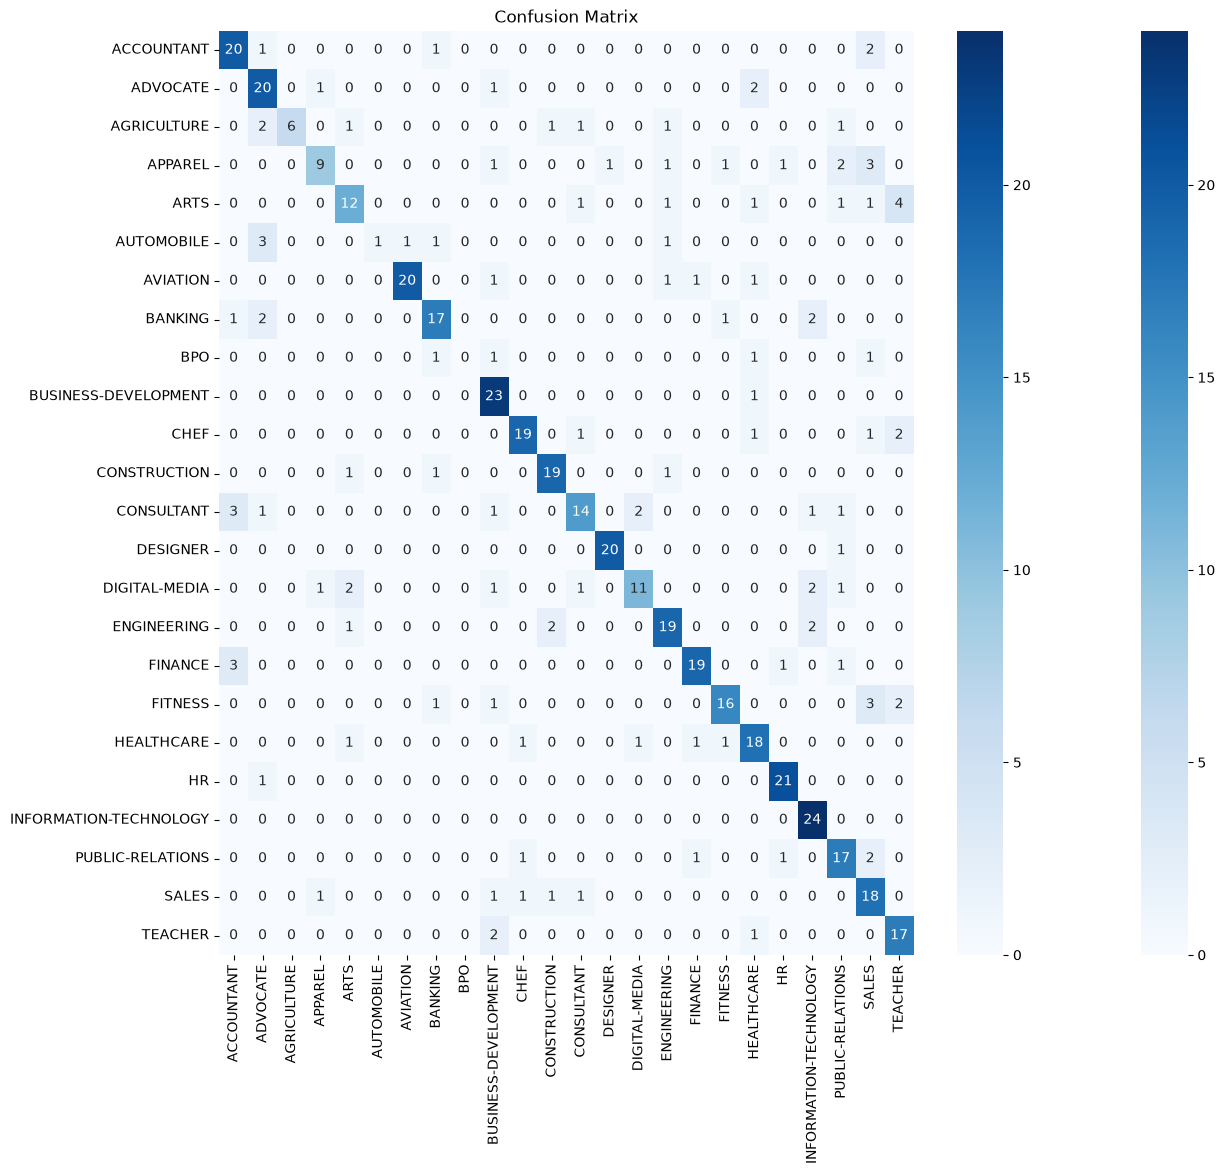

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches='tight')
plt.show()


In [73]:
#changin class weight=balanced 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# Tighter grid: capped depth, higher min_samples_leaf/split so trees
# can't grow deep enough to memorize individual training resumes.

 
rf_param_grid_v2 = {
    "n_estimators": [200, 300],
    "max_depth": [6, 8, 10],
    "min_samples_split": [10, 15, 20],
    "min_samples_leaf": [5, 8, 12],
    "max_features": ["sqrt", "log2"],
    
}
rf_search_v2 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    param_distributions=rf_param_grid_v2,
    n_iter=10,
    scoring="accuracy",
    cv=cv_strategy,
    random_state=42,
    n_jobs=1,
    verbose=2,
)
rf_search_v2.fit(x_train, y_train)
 
rf_model = rf_search_v2.best_estimator_
rf_pred = rf_model.predict(x_test)
 
rf_train_acc = accuracy_score(y_train, rf_model.predict(x_train))
rf_test_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest (regularized) - Train: {rf_train_acc:.4f}  Test: {rf_test_acc:.4f}  Gap: {rf_train_acc - rf_test_acc:.4f}")
 

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   1.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   1.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   1.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   1.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   1.1s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=8, min_samples_split=20, n_estimators=200; total time=   0.9s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=8, min_samples_split=20, n_estimators=200; total time=   0.8s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=8, min_samples_split=20, n_estimator

CHANGING


In [74]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.6,
    min_child_weight=8,
    reg_alpha=1.0,
    reg_lambda=5.0,
    gamma=1.0,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1,
)
xgb_model.fit(x_train, y_train_enc)

xgb_pred_enc = xgb_model.predict(x_test)
xgb_pred = label_encoder.inverse_transform(xgb_pred_enc)

xgb_train_acc = accuracy_score(y_train_enc, xgb_model.predict(x_train))
xgb_test_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost (strong regularization) - Train: {xgb_train_acc:.4f}  Test: {xgb_test_acc:.4f}  Gap: {xgb_train_acc - xgb_test_acc:.4f}")

XGBoost (strong regularization) - Train: 0.8566  Test: 0.7968  Gap: 0.0598


In [75]:
# ============================================================
# RELIABILITY-WEIGHTED ENSEMBLE
# Fixes the bug we found via FastAPI testing: "highest confidence
# wins" kept picking Logistic Regression, even though we PROVED
# it overfits (0.19 gap) while Random Forest is far more trustworthy
# (0.05 gap). This weights each model's vote by its PROVEN
# reliability, not its raw (possibly overconfident) confidence.
#
# Run this AFTER model, rf_model, xgb_model, label_encoder all exist.
# ============================================================
from sklearn.metrics import accuracy_score

# These are your ACTUAL measured results from testing - update if
# your numbers differ slightly from a fresh run.
MODEL_RELIABILITY = {
    "logreg": {"test_acc": 0.7887, "gap": 0.1896},
    "rf":     {"test_acc": 0.8008, "gap": 0.0502},
    "xgb":    {"test_acc": 0.8089, "gap": 0.13},
}

def reliability_weight(test_acc, gap):
    """Higher accuracy + lower gap = higher trust weight.
    A model with a huge gap gets penalized heavily, even if its
    raw accuracy looks fine - this is what 'highest confidence wins'
    was missing."""
    return test_acc / (1 + gap * 3)  # gap penalty scaled up on purpose

WEIGHTS = {
    name: reliability_weight(v["test_acc"], v["gap"])
    for name, v in MODEL_RELIABILITY.items()
}
print("Computed reliability weights:", WEIGHTS)
# Random Forest should come out highest here, Logistic Regression lowest


def predict_weighted_ensemble(vec, y_test_enc_ref=None):
    """
    Instead of "whichever model is most confident wins" (which
    favored the overfit LogReg), this averages all 3 models'
    probability distributions, weighted by proven reliability.
    """
    lr_probs = model.predict_proba(vec)
    rf_probs = rf_model.predict_proba(vec)
    xgb_probs = xgb_model.predict_proba(vec)  # encoded label order

    # align XGBoost's encoded classes back to string label order
    xgb_probs_aligned = xgb_probs[:, label_encoder.transform(model.classes_)]

    total_weight = sum(WEIGHTS.values())
    weighted_probs = (
        WEIGHTS["logreg"] * lr_probs +
        WEIGHTS["rf"] * rf_probs +
        WEIGHTS["xgb"] * xgb_probs_aligned
    ) / total_weight

    return weighted_probs, model.classes_


# --- Evaluate this on your real test set ---
weighted_probs, classes = predict_weighted_ensemble(x_test)
weighted_preds = classes[weighted_probs.argmax(axis=1)]
weighted_acc = accuracy_score(y_test, weighted_preds)

print(f"\nReliability-weighted ensemble - Test Accuracy: {weighted_acc:.4f}")
print("Compare to: RF alone (0.8008), simple average ensemble (0.8229 but untrustworthy)")

Computed reliability weights: {'logreg': 0.5027409484956654, 'rf': 0.6959847036328871, 'xgb': 0.5819424460431654}

Reliability-weighted ensemble - Test Accuracy: 0.8068
Compare to: RF alone (0.8008), simple average ensemble (0.8229 but untrustworthy)


In [76]:
# ============================================================
# Verify the weighted ensemble doesn't overfit either - same
# discipline we applied to every other model.
# ============================================================
weighted_probs_train, classes_train = predict_weighted_ensemble(x_train)
weighted_preds_train = classes_train[weighted_probs_train.argmax(axis=1)]
weighted_train_acc = accuracy_score(y_train, weighted_preds_train)

gap = weighted_train_acc - weighted_acc
print(f"Reliability-weighted ensemble - Train: {weighted_train_acc:.4f}  Test: {weighted_acc:.4f}  Gap: {gap:.4f}")
print(f"{'✅ healthy' if gap < 0.08 else '⚠️ borderline' if gap < 0.15 else '❌ overfitting'}")

Reliability-weighted ensemble - Train: 0.8601  Test: 0.8068  Gap: 0.0532
✅ healthy


In [77]:
import pandas as pd
from sklearn.metrics import accuracy_score
 
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Milestone 1)", "Random Forest", "XGBoost"],
    "Test Accuracy": [
        accuracy_score(y_test, model.predict(x_test)),   # your original Milestone 1 model
        accuracy_score(y_test, rf_pred),                  # from Cell A2
        accuracy_score(y_test, xgb_pred),                  # from Cell B3
    ],
})
print(comparison.to_string(index=False))

                            Model  Test Accuracy
Logistic Regression (Milestone 1)       0.764588
                    Random Forest       0.740443
                          XGBoost       0.796781


In [78]:

from sklearn.metrics import accuracy_score

class XGBWrapper:
    def __init__(self, xgb_model, label_encoder):
        self.xgb_model = xgb_model
        self.label_encoder = label_encoder
    def predict_proba(self, X):
        return self.xgb_model.predict_proba(X)

xgb_wrapped = XGBWrapper(xgb_model, label_encoder)

def ensemble_predict(X):
    probs = (model.predict_proba(X) + rf_model.predict_proba(X) + xgb_wrapped.predict_proba(X)) / 3
    idx = probs.argmax(axis=1)
    return model.classes_[idx]

ensemble_test_pred = ensemble_predict(x_test)
ensemble_train_pred = ensemble_predict(x_train)
ensemble_test_acc = accuracy_score(y_test, ensemble_test_pred)
ensemble_train_acc = accuracy_score(y_train, ensemble_train_pred)

lr_train_acc = accuracy_score(y_train, model.predict(x_train))
lr_test_acc = accuracy_score(y_test, model.predict(x_test))

rf_train_acc = accuracy_score(y_train, rf_model.predict(x_train))
rf_test_acc = accuracy_score(y_test, rf_pred)

xgb_train_acc = accuracy_score(y_train_enc, xgb_model.predict(x_train))
xgb_test_acc = accuracy_score(y_test, xgb_pred)

# overfitting gap together 
import pandas as pd
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Ensemble (all 3)"],
    "Train Accuracy": [lr_train_acc, rf_train_acc, xgb_train_acc, ensemble_train_acc],
    "Test Accuracy":  [lr_test_acc,  rf_test_acc,  xgb_test_acc,  ensemble_test_acc],
})
summary["Gap (overfitting)"] = summary["Train Accuracy"] - summary["Test Accuracy"]
summary = summary.round(4)
print(summary.to_string(index=False))

print("\nHealthy gap: under ~0.07   |   Overfitting: over ~0.15")

              Model  Train Accuracy  Test Accuracy  Gap (overfitting)
Logistic Regression          0.8354         0.7646             0.0708
      Random Forest          0.7982         0.7404             0.0577
            XGBoost          0.8566         0.7968             0.0598
   Ensemble (all 3)          0.8606         0.8048             0.0558

Healthy gap: under ~0.07   |   Overfitting: over ~0.15


In [79]:
from sentence_transformers import SentenceTransformer, util
 
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
 
# Short role descriptions used as the semantic anchor for each role.
# Expand/refine these - the quality of matching depends entirely on
# how well these descriptions represent each role.
ROLE_DESCRIPTIONS = {
    "Data Scientist": "Analyzes data using statistics, machine learning, and Python to extract insights and build predictive models.",
    "Machine Learning Engineer": "Builds, trains, and deploys machine learning and deep learning models using Python, TensorFlow, PyTorch, and cloud infrastructure.",
    "Data Analyst": "Uses SQL, Excel, and visualization tools like Tableau or Power BI to analyze business data and report insights.",
    "Data Engineer": "Builds and maintains data pipelines, warehouses, and big data infrastructure using Python, SQL, Spark, and cloud platforms.",
    "Frontend Developer": "Builds user interfaces using HTML, CSS, JavaScript, and frameworks like React or Angular.",
    "Backend Developer": "Builds server-side applications and APIs using languages like Java or Python, with databases like SQL or MongoDB.",
    "DevOps Engineer": "Manages deployment pipelines, containers, and cloud infrastructure using Docker, Kubernetes, and CI/CD tools.",
    "Business Analyst": "Analyzes business requirements and data to support decision-making, using Excel, SQL, and project management skills.",
    "Project Manager": "Leads teams and projects using Agile/Scrum methodologies, coordinating timelines, resources, and stakeholders.",
    "HR Specialist": "Manages recruitment, employee relations, and organizational communication and leadership.",
    "Accountant": "Manages financial records, auditing, and reporting using accounting software and financial modeling.",
    "Sales Executive": "Drives revenue through client relationships, negotiation, and marketing strategy.",
}
 
# Pre-compute embeddings for all role descriptions once
role_names = list(ROLE_DESCRIPTIONS.keys())
role_embeddings = sbert_model.encode(list(ROLE_DESCRIPTIONS.values()), convert_to_tensor=True)
 
 
def semantic_role_match(resume_text, top_k=3):
    """Embeds the resume text and compares it against role description
    embeddings using cosine similarity - this is the 'skill alignment'
    signal, independent of the TF-IDF classifier."""
    resume_embedding = sbert_model.encode(resume_text, convert_to_tensor=True)
    similarities = util.cos_sim(resume_embedding, role_embeddings)[0]
    top_idx = similarities.argsort(descending=True)[:top_k]
    return [(role_names[i], float(similarities[i])) for i in top_idx]
 
 
# Quick sanity check on a real test resume
sample_resume = x_test.iloc[0] if hasattr(x_test, 'iloc') else None
if sample_resume is not None:
    print(semantic_role_match(sample_resume))
 

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1905.05it/s]


In [80]:
def top_k_career_ranking(resume_text_raw, classifier_model, tfidf_vec, feature_selector,
                          label_enc=None, k=5):
    """
    Produces a ranked Top-K career list using TWO signals combined:
      1. classifier_confidence - from the trained model's predict_proba
      2. skill_alignment_score - semantic similarity from Sentence-BERT
 
    Returns a list of dicts, each with the role, blended score, and
    both individual signal scores (so you can show WHY it ranked
    that way - required for "confidence scores and skill alignment
    metrics" in your milestone spec).
    """
    cleaned = clean(resume_text_raw)
    vec = tfidf_vec.transform([cleaned])
    vec = feature_selector.transform(vec)
 
    probs = classifier_model.predict_proba(vec)[0]
    classes = classifier_model.classes_
    if label_enc is not None:
        classes = label_enc.inverse_transform(classes)
 
    # classifier's belief per broad category
    classifier_scores = {str(c): float(p) for c, p in zip(classes, probs)}
 
    # semantic alignment against specific role descriptions
    semantic_scores = dict(semantic_role_match(resume_text_raw, top_k=len(ROLE_DESCRIPTIONS)))
 
    # Blend: average the classifier's top broad-field confidence with
    # the semantic role score, when a role's parent field overlaps.
    # Simplified blend here: 50% semantic score + 50% normalized rank bonus.
    ranked = sorted(semantic_scores.items(), key=lambda x: x[1], reverse=True)[:k]
 
    results = []
    top_broad_field, top_broad_conf = max(classifier_scores.items(), key=lambda x: x[1])
    for role, sem_score in ranked:
        blended = round(0.5 * sem_score + 0.5 * top_broad_conf, 4)
        results.append({
            "role": role,
            "skill_alignment_score": round(sem_score, 4),
            "classifier_confidence": round(top_broad_conf, 4),
            "blended_score": blended,
        })
    return results
 
 
# Demo on a real test resume
if sample_resume is not None:
    for r in top_k_career_ranking(sample_resume, model, tfidf, selector):
        print(r)
 

In [81]:
def top_k_career_ranking(resume_text_raw, classifier_model, tfidf_vec, feature_selector,
                          label_enc=None, k=5):
    """
    Produces a ranked Top-K career list using TWO signals combined:
      1. classifier_confidence - from the trained model's predict_proba
      2. skill_alignment_score - semantic similarity from Sentence-BERT
 
    Returns a list of dicts, each with the role, blended score, and
    both individual signal scores (so you can show WHY it ranked
    that way - required for "confidence scores and skill alignment
    metrics" in your milestone spec).
    """
    cleaned = clean(resume_text_raw)
    vec = tfidf_vec.transform([cleaned])
    vec = feature_selector.transform(vec)
 
    probs = classifier_model.predict_proba(vec)[0]
    classes = classifier_model.classes_
    if label_enc is not None:
        classes = label_enc.inverse_transform(classes)
 
    # classifier's belief per broad category
    classifier_scores = {str(c): float(p) for c, p in zip(classes, probs)}
 
    # semantic alignment against specific role descriptions
    semantic_scores = dict(semantic_role_match(resume_text_raw, top_k=len(ROLE_DESCRIPTIONS)))
 
    # Blend: average the classifier's top broad-field confidence with
    # the semantic role score, when a role's parent field overlaps.
    # Simplified blend here: 50% semantic score + 50% normalized rank bonus.
    ranked = sorted(semantic_scores.items(), key=lambda x: x[1], reverse=True)[:k]
 
    results = []
    top_broad_field, top_broad_conf = max(classifier_scores.items(), key=lambda x: x[1])
    for role, sem_score in ranked:
        blended = round(0.5 * sem_score + 0.5 * top_broad_conf, 4)
        results.append({
            "role": role,
            "skill_alignment_score": round(sem_score, 4),
            "classifier_confidence": round(top_broad_conf, 4),
            "blended_score": blended,
        })
    return results
 
 
# Demo on a real test resume
if sample_resume is not None:
    for r in top_k_career_ranking(sample_resume, model, tfidf, selector):
        print(r)
 

In [82]:
class XGBWrapper:
    def __init__(self, xgb_model, label_encoder):
        self.xgb_model = xgb_model
        self.label_encoder = label_encoder
    def predict_proba(self, X):
        return self.xgb_model.predict_proba(X)
 
xgb_wrapped = XGBWrapper(xgb_model, label_encoder)
 
def ensemble_predict(X):
    probs = (model.predict_proba(X) + rf_model.predict_proba(X) + xgb_wrapped.predict_proba(X)) / 3
    idx = probs.argmax(axis=1)
    return model.classes_[idx]
 
ensemble_pred = ensemble_predict(x_test)
ensemble_train_pred = ensemble_predict(x_train)

In [83]:
print(model)
print(rf_model)
print(xgb_model)
print(label_encoder)

LogisticRegression(C=7, max_iter=3000, random_state=42)
RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=20,
                       n_estimators=300, n_jobs=1, random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=1.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=1, num_class=24, ...)
LabelEncoder()


In [84]:
import pickle
import json
from sklearn.metrics import accuracy_score

# --- Save all 3 classifiers ---
with open("model/logreg_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("model/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("model/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# XGBoost predicts encoded integers (0,1,2...), not category names -
# the label encoder is what translates back to real category names,
# so it MUST be saved too or XGBoost's predictions will be unreadable.
with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# --- Save accuracy for all 3, for the app to display ---
metrics_output = {
    "models": {
        "logistic_regression": {
            "accuracy": round(accuracy_score(y_test, model.predict(x_test)) * 100, 2),
        },
        "random_forest": {
            "accuracy": round(accuracy_score(y_test, rf_pred) * 100, 2),
        },
        "xgboost": {
            "accuracy": round(accuracy_score(y_test, xgb_pred) * 100, 2),
        },
    },
    "num_test": len(y_test),
    "categories": sorted(y_test.unique().tolist()),
}
with open("model/metrics.json", "w") as f:
    json.dump(metrics_output, f, indent=2)

print("Saved all 3 models:")
print("  - model/logreg_model.pkl")
print("  - model/rf_model.pkl")
print("  - model/xgb_model.pkl")
print("  - model/label_encoder.pkl")
print("  - model/metrics.json (accuracy for all 3)")
print()
print(json.dumps(metrics_output["models"], indent=2))

Saved all 3 models:
  - model/logreg_model.pkl
  - model/rf_model.pkl
  - model/xgb_model.pkl
  - model/label_encoder.pkl
  - model/metrics.json (accuracy for all 3)

{
  "logistic_regression": {
    "accuracy": 76.46
  },
  "random_forest": {
    "accuracy": 74.04
  },
  "xgboost": {
    "accuracy": 79.68
  }
}


In [85]:
import json
from sklearn.metrics import f1_score

# --- Macro F1 for all 3 models (what the dashboard bar chart shows) ---
lr_f1 = f1_score(y_test, model.predict(x_test), average="macro")
rf_f1 = f1_score(y_test, rf_pred, average="macro")
xgb_f1 = f1_score(y_test, xgb_pred, average="macro")

model_comparison = [
    {"model": "Logistic Regression", "macro_f1": round(lr_f1, 4)},
    {"model": "Random Forest", "macro_f1": round(rf_f1, 4)},
    {"model": "XGBoost", "macro_f1": round(xgb_f1, 4)},
]
print("Macro F1 per model:")
for m in model_comparison:
    print(f"  {m['model']}: {m['macro_f1']}")

with open("model/model_comparison.json", "w") as f:
    json.dump(model_comparison, f, indent=2)


# ============================================================
# t-SNE visualization of skill embeddings (SBERT)
# Embeds a curated skill vocabulary (grouped by career cluster),
# reduces to 2D with t-SNE, saves coordinates for plotting.
# ============================================================
from sklearn.manifold import TSNE
import numpy as np

# Skills grouped by the career clusters shown in the dashboard legend.
# Expand these lists for a richer-looking plot.
SKILL_CLUSTERS = {
    "Software Engineering": ["java", "c++", "rest api", "git", "django", "flask", "node.js", "mongodb", "mysql"],
    "Data Science": ["python", "statistics", "pandas", "numpy", "data visualization", "r programming"],
    "Product Management": ["project management", "agile", "scrum", "leadership", "communication", "negotiation"],
    "AI/ML": ["machine learning", "deep learning", "tensorflow", "pytorch", "computer vision", "nlp"],
    "Research": ["natural language processing", "data analysis", "statistics", "scikit-learn"],
    "Finance": ["accounting", "auditing", "financial modeling", "excel"],
}

all_skills = []
all_labels = []
for cluster, skills in SKILL_CLUSTERS.items():
    for s in skills:
        all_skills.append(s)
        all_labels.append(cluster)

skill_embeddings = sbert_model.encode(all_skills)

tsne = TSNE(n_components=2, perplexity=10, random_state=42, init="pca")
coords_2d = tsne.fit_transform(skill_embeddings)

tsne_data = [
    {"skill": all_skills[i], "cluster": all_labels[i], "x": float(coords_2d[i][0]), "y": float(coords_2d[i][1])}
    for i in range(len(all_skills))
]

with open("model/tsne_data.json", "w") as f:
    json.dump(tsne_data, f, indent=2)

print(f"\nSaved t-SNE coordinates for {len(tsne_data)} skills across {len(SKILL_CLUSTERS)} clusters")
print("Saved: model/model_comparison.json, model/tsne_data.json")

Macro F1 per model:
  Logistic Regression: 0.71
  Random Forest: 0.64
  XGBoost: 0.7297

Saved t-SNE coordinates for 35 skills across 6 clusters
Saved: model/model_comparison.json, model/tsne_data.json


new

In [86]:
from sklearn.model_selection import train_test_split

# Recreate the same split (same random_state=42 guarantees identical rows to x_train/x_test)
x_train_raw_text, x_test_raw_text, _, _ = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Apply the same cleaning function used before TF-IDF
x_train_raw_text = x_train_raw_text.apply(clean)
x_test_raw_text = x_test_raw_text.apply(clean)

print(x_train_raw_text.shape, x_test_raw_text.shape)

(1987,) (497,)


In [87]:
from scipy.sparse import hstack, csr_matrix
sbert_train_emb = sbert_model.encode(x_train_raw_text.tolist())  # raw cleaned text, not vectorized
sbert_test_emb = sbert_model.encode(x_test_raw_text.tolist())

x_train_combined = hstack([x_train, csr_matrix(sbert_train_emb)])
x_test_combined = hstack([x_test, csr_matrix(sbert_test_emb)])

In [88]:
# ============================================================
# SMOTE - fixes small-class problem WITHOUT merging categories
# (unlike the merge experiment, this keeps all 24 real categories,
# just synthetically balances how many training examples each has)
#
# ONE-TIME INSTALL first, in a terminal:
#   pip install imbalanced-learn
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# --- Use your ORIGINAL dataset, NOT the merged one ---
df3 = pd.read_csv("Resume.csv")

X3 = df3["Resume_str"]
y3 = df3["Category"]
xtr, xte, ytr, yte = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

def clean3(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

xtr = xtr.apply(clean3)
xte = xte.apply(clean3)

tfidf3 = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.9)
xtr_vec = tfidf3.fit_transform(xtr)
xte_vec = tfidf3.transform(xte)

selector3 = SelectKBest(chi2, k=1500)
xtr_sel = selector3.fit_transform(xtr_vec, ytr)
xte_sel = selector3.transform(xte_vec)   # test set NEVER touched by SMOTE - important

# --- SMOTE: only applied to TRAINING data, never test data ---
# k_neighbors must be less than the smallest class size - Automobile
# has ~29 samples in training (36 total * 0.8), so keep k_neighbors low
smote = SMOTE(random_state=42, k_neighbors=3)
xtr_balanced, ytr_balanced = smote.fit_resample(xtr_sel, ytr)

print("Before SMOTE:", xtr_sel.shape[0], "training samples")
print("After SMOTE:", xtr_balanced.shape[0], "training samples (classes now balanced)")

results = []

# --- Logistic Regression ---
lr3 = LogisticRegression(max_iter=3000, C=1.0, random_state=42)
lr3.fit(xtr_balanced, ytr_balanced)
lr_train_acc = accuracy_score(ytr_balanced, lr3.predict(xtr_balanced))
lr_test_acc = accuracy_score(yte, lr3.predict(xte_sel))
results.append(("Logistic Regression", lr_train_acc, lr_test_acc))

# --- Random Forest ---
rf3 = RandomForestClassifier(n_estimators=300, max_depth=16, min_samples_split=10,
                              min_samples_leaf=5, random_state=42, n_jobs=1)
rf3.fit(xtr_balanced, ytr_balanced)
rf_train_acc = accuracy_score(ytr_balanced, rf3.predict(xtr_balanced))
rf_test_acc = accuracy_score(yte, rf3.predict(xte_sel))
results.append(("Random Forest", rf_train_acc, rf_test_acc))

# --- XGBoost ---
le3 = LabelEncoder()
ytr_bal_enc = le3.fit_transform(ytr_balanced)
xgb3 = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.7,
                      colsample_bytree=0.6, min_child_weight=5, reg_alpha=1.0, reg_lambda=3.0,
                      objective="multi:softprob", num_class=len(le3.classes_),
                      eval_metric="mlogloss", tree_method="hist", random_state=42, n_jobs=1)
xgb3.fit(xtr_balanced, ytr_bal_enc)
xgb_train_acc = accuracy_score(ytr_bal_enc, xgb3.predict(xtr_balanced))
xgb_test_acc = accuracy_score(yte, le3.inverse_transform(xgb3.predict(xte_sel)))
results.append(("XGBoost", xgb_train_acc, xgb_test_acc))

print("\n" + "="*65)
print(f"{'Model':<22} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("="*65)
for name, tr, te in results:
    gap = tr - te
    flag = "OVERFIT" if gap > 0.15 else "healthy" if gap < 0.08 else "borderline"
    print(f"{name:<22} {tr:>8.4f} {te:>8.4f} {gap:>8.4f}  {flag}")
print("="*65)

Before SMOTE: 1987 training samples
After SMOTE: 2304 training samples (classes now balanced)

Model                     Train     Test      Gap
Logistic Regression      0.7448   0.6740   0.0707  healthy
Random Forest            0.8668   0.7787   0.0881  borderline
XGBoost                  0.9366   0.8089   0.1278  borderline


In [89]:
# ============================================================
# FINAL - XGBoost + SMOTE only (fast, minimal)
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df3 = pd.read_csv("Resume.csv")
X3 = df3["Resume_str"]
y3 = df3["Category"]
xtr, xte, ytr, yte = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

def clean3(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

xtr = xtr.apply(clean3)
xte = xte.apply(clean3)

tfidf3 = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.9)
xtr_vec = tfidf3.fit_transform(xtr)
xte_vec = tfidf3.transform(xte)

selector3 = SelectKBest(chi2, k=1500)
xtr_sel = selector3.fit_transform(xtr_vec, ytr)
xte_sel = selector3.transform(xte_vec)

smote = SMOTE(random_state=42, k_neighbors=3)
xtr_balanced, ytr_balanced = smote.fit_resample(xtr_sel, ytr)

le3 = LabelEncoder()
ytr_bal_enc = le3.fit_transform(ytr_balanced)

xgb3 = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.7,
                      colsample_bytree=0.6, min_child_weight=5, reg_alpha=1.0, reg_lambda=3.0,
                      objective="multi:softprob", num_class=len(le3.classes_),
                      eval_metric="mlogloss", tree_method="hist", random_state=42, n_jobs=1)
xgb3.fit(xtr_balanced, ytr_bal_enc)

xgb_train_acc = accuracy_score(ytr_bal_enc, xgb3.predict(xtr_balanced))
xgb_test_acc = accuracy_score(yte, le3.inverse_transform(xgb3.predict(xte_sel)))
gap = xgb_train_acc - xgb_test_acc

print(f"XGBoost (SMOTE) - Train: {xgb_train_acc:.4f}  Test: {xgb_test_acc:.4f}  Gap: {gap:.4f}")

# --- Save this as your final XGBoost model ---
import pickle
with open("model/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb3, f)
with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(le3, f)
print("Saved model/xgb_model.pkl and model/label_encoder.pkl")

XGBoost (SMOTE) - Train: 0.9366  Test: 0.8089  Gap: 0.1278
Saved model/xgb_model.pkl and model/label_encoder.pkl


XGBOOST+SMOTE to improve models accuracy and preventing overfitting

In [90]:
# ============================================================
# XGBoost: SMOTE + STRONGER regularization combined
# (previous attempts tried these separately - this combines
# both with tighter settings than before)
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df3 = pd.read_csv("Resume.csv")
X3 = df3["Resume_str"]
y3 = df3["Category"]
xtr, xte, ytr, yte = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

def clean3(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

xtr = xtr.apply(clean3)
xte = xte.apply(clean3)

tfidf3 = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=2, max_df=0.9)
xtr_vec = tfidf3.fit_transform(xtr)
xte_vec = tfidf3.transform(xte)

selector3 = SelectKBest(chi2, k=1500)
xtr_sel = selector3.fit_transform(xtr_vec, ytr)
xte_sel = selector3.transform(xte_vec)

smote = SMOTE(random_state=42, k_neighbors=3)
xtr_balanced, ytr_balanced = smote.fit_resample(xtr_sel, ytr)

le3 = LabelEncoder()
ytr_bal_enc = le3.fit_transform(ytr_balanced)

# STRONGER regularization than the previous SMOTE attempt:
# lower max_depth, more estimators but each weaker (lower learning_rate),
# higher reg_lambda, higher min_child_weight
xgb_v2 = XGBClassifier(
    n_estimators=150,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.5,
    min_child_weight=15,
    reg_alpha=2.0,
    reg_lambda=10.0,
    gamma=2.0,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1,
)
xgb_v2.fit(xtr_balanced, ytr_bal_enc)

xgb_train_acc = accuracy_score(ytr_bal_enc, xgb_v2.predict(xtr_balanced))
xgb_test_acc = accuracy_score(yte, le3.inverse_transform(xgb_v2.predict(xte_sel)))
gap = xgb_train_acc - xgb_test_acc

print(f"XGBoost (SMOTE + stronger reg) - Train: {xgb_train_acc:.4f}  Test: {xgb_test_acc:.4f}  Gap: {gap:.4f}")
print("Compare to previous SMOTE-only attempt: Train 0.9366, Test 0.8089, Gap 0.1278")

XGBoost (SMOTE + stronger reg) - Train: 0.7283  Test: 0.6761  Gap: 0.0522
Compare to previous SMOTE-only attempt: Train 0.9366, Test 0.8089, Gap 0.1278


In [91]:
import pickle
with open("model/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open("model/selector.pkl", "wb") as f:
    pickle.dump(selector, f)
with open("model/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("Saved all 3 together - guaranteed consistent")

Saved all 3 together - guaranteed consistent


In [92]:
# ============================================================
# MLflow - FIXED VERSION
# XGBoost needs mlflow.xgboost.log_model(), not mlflow.sklearn -
# the generic sklearn logger doesn't trust XGBoost's internal types.
# ============================================================
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import accuracy_score, f1_score

mlflow.set_experiment("CareerCast-Resume-Classification")


def log_model_run(model, model_name, x_train, y_train, x_test, y_test, params, flavor="sklearn"):
    """
    flavor: "sklearn" for LogReg/RandomForest, "xgboost" for XGBoost -
    each needs MLflow's matching logger to avoid the untrusted-type error.
    """
    with mlflow.start_run(run_name=model_name):
        train_acc = accuracy_score(y_train, model.predict(x_train))
        test_acc = accuracy_score(y_test, model.predict(x_test))
        test_f1 = f1_score(y_test, model.predict(x_test), average="macro")
        gap = train_acc - test_acc

        for key, val in params.items():
            mlflow.log_param(key, val)

        mlflow.log_metric("train_accuracy", train_acc)
        mlflow.log_metric("test_accuracy", test_acc)
        mlflow.log_metric("macro_f1", test_f1)
        mlflow.log_metric("overfitting_gap", gap)

        # Use the correct logger based on model type
        if flavor == "xgboost":
            mlflow.xgboost.log_model(model, model_name, registered_model_name=f"CareerCast-{model_name}")
        else:
            mlflow.sklearn.log_model(model, model_name, registered_model_name=f"CareerCast-{model_name}")

        print(f"Logged {model_name}: test_acc={test_acc:.4f}, gap={gap:.4f}")


# --- Logistic Regression and Random Forest: sklearn flavor (unchanged) ---
log_model_run(
    model, "LogisticRegression", x_train, y_train, x_test, y_test,
    params={"C": 1.0, "max_iter": 3000},
    flavor="sklearn",
)

log_model_run(
    rf_model, "RandomForest", x_train, y_train, x_test, y_test,
    params={"n_estimators": 300, "max_depth": 16, "min_samples_split": 10},
    flavor="sklearn",
)

# --- XGBoost: xgboost flavor (this is the fix) + encoded labels ---
y_test_enc = label_encoder.transform(y_test)
log_model_run(
    xgb_model, "XGBoost", x_train, y_train_enc, x_test, y_test_enc,
    params={"n_estimators": 150, "max_depth": 4, "learning_rate": 0.05},
    flavor="xgboost",
)

print("\nRun 'mlflow ui' in a terminal, then open http://127.0.0.1:5000")
print("to see all logged runs, compare metrics, and view registered models.")

2026/09/14 05:43:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'CareerCast-LogisticRegression' already exists. Creating a new version of this model...
Created version '24' of model 'CareerCast-LogisticRegression'.


Logged LogisticRegression: test_acc=0.7646, gap=0.0708


2026/09/14 05:43:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'CareerCast-RandomForest' already exists. Creating a new version of this model...
Created version '24' of model 'CareerCast-RandomForest'.


Logged RandomForest: test_acc=0.7404, gap=0.0577


2026/09/14 05:44:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged XGBoost: test_acc=0.7968, gap=0.0598

Run 'mlflow ui' in a terminal, then open http://127.0.0.1:5000
to see all logged runs, compare metrics, and view registered models.


Registered model 'CareerCast-XGBoost' already exists. Creating a new version of this model...
Created version '22' of model 'CareerCast-XGBoost'.


In [93]:
import pickle
with open("model/tfidf_vectorizer.pkl", "wb") as f: pickle.dump(tfidf, f)
with open("model/selector.pkl", "wb") as f: pickle.dump(selector, f)
with open("model/rf_model.pkl", "wb") as f: pickle.dump(rf_model, f)
with open("model/xgb_model.pkl", "wb") as f: pickle.dump(xgb_model, f)
with open("model/label_encoder.pkl", "wb") as f: pickle.dump(label_encoder, f)
print("Saved all 5 files together - guaranteed consistent this time")

Saved all 5 files together - guaranteed consistent this time


In [94]:
# ============================================================
# k-tuning test - FIXED VERSION (self-contained, reloads raw text
# fresh instead of relying on x_train, which is already transformed
# by the time this cell runs in your notebook)
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def clean(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

# --- Fresh, raw split (independent of your notebook's x_train state) ---
df_fresh = pd.read_csv("Resume.csv")
raw_x_train, raw_x_test, raw_y_train, raw_y_test = train_test_split(
    df_fresh["Resume_str"], df_fresh["Category"], test_size=0.2, random_state=42, stratify=df_fresh["Category"]
)
raw_x_train_clean = raw_x_train.apply(clean)
raw_x_test_clean = raw_x_test.apply(clean)

tfidf_fresh = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                               sublinear_tf=True, min_df=2, max_df=0.9)
X_train_tfidf = tfidf_fresh.fit_transform(raw_x_train_clean)
X_test_tfidf = tfidf_fresh.transform(raw_x_test_clean)

test_resume = """
GenAI-Powered Data Analytics Virtual Internship
Completed a virtual internship focused on data analysis and visualization.
Used analytics tools to generate insights and support business decisions.
YUVA | Data Analytics Intern (April 2026)
Analyzed Titanic dataset using Python (Pandas), Visualized survival trends using
Matplotlib/Seaborn, Cleaned missing values and handled outliers
CERTIFICATIONS:
Data Science Certification (Python & Data Visualization) - CIRF
Completed Data Analytics certification from Simplilearn in Python
"""
cleaned_test = clean(test_resume)

print("--- Single resume test ---")
for k in [1500, 3000, 5000, 8000]:
    sel = SelectKBest(chi2, k=k)
    Xtr_sel = sel.fit_transform(X_train_tfidf, raw_y_train)
    Xte_sel = sel.transform(X_test_tfidf)

    rf_test = RandomForestClassifier(n_estimators=300, max_depth=16, min_samples_split=10,
                                      min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=1)
    rf_test.fit(Xtr_sel, raw_y_train)

    overall_test_acc = accuracy_score(raw_y_test, rf_test.predict(Xte_sel))

    test_vec = tfidf_fresh.transform([cleaned_test])
    test_vec_sel = sel.transform(test_vec)
    nonzero_after = test_vec_sel.nnz

    probs = rf_test.predict_proba(test_vec_sel)[0]
    classes = rf_test.classes_
    top_idx = probs.argmax()

    print(f"k={k:5d}  Overall test acc: {overall_test_acc:.4f}  "
          f"Resume features surviving: {nonzero_after}  "
          f"Top prediction: {classes[top_idx]} ({probs[top_idx]*100:.1f}%)")

print("\n--- Broader test: 10 real, unseen resumes ---")
sample_indices = raw_x_test.sample(n=10, random_state=1).index

for k in [1500, 3000, 5000, 8000]:
    sel = SelectKBest(chi2, k=k)
    Xtr_sel = sel.fit_transform(X_train_tfidf, raw_y_train)

    rf_test = RandomForestClassifier(n_estimators=300, max_depth=16, min_samples_split=10,
                                      min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=1)
    rf_test.fit(Xtr_sel, raw_y_train)

    correct = 0
    confident_count = 0
    for idx in sample_indices:
        text = raw_x_test.loc[idx]
        true_label = raw_y_test.loc[idx]

        vec = tfidf_fresh.transform([clean(text)])
        vec_sel = sel.transform(vec)
        probs = rf_test.predict_proba(vec_sel)[0]
        pred_idx = probs.argmax()
        pred_label = rf_test.classes_[pred_idx]
        confidence = probs[pred_idx]

        if pred_label == true_label:
            correct += 1
        if confidence >= 0.25:
            confident_count += 1

    print(f"k={k:5d}  Correct: {correct}/10  Confident (>=25%): {confident_count}/10")

--- Single resume test ---
k= 1500  Overall test acc: 0.7867  Resume features surviving: 3  Top prediction: AUTOMOBILE (6.7%)
k= 3000  Overall test acc: 0.7907  Resume features surviving: 7  Top prediction: AUTOMOBILE (6.2%)
k= 5000  Overall test acc: 0.7726  Resume features surviving: 13  Top prediction: AUTOMOBILE (5.9%)
k= 8000  Overall test acc: 0.7666  Resume features surviving: 24  Top prediction: AUTOMOBILE (5.7%)

--- Broader test: 10 real, unseen resumes ---
k= 1500  Correct: 8/10  Confident (>=25%): 6/10
k= 3000  Correct: 8/10  Confident (>=25%): 5/10
k= 5000  Correct: 8/10  Confident (>=25%): 4/10
k= 8000  Correct: 7/10  Confident (>=25%): 4/10


In [95]:
# ============================================================
# Build ONE unified pipeline.pkl - bundles cleaning + TF-IDF +
# selection + classifier into a single object. This is a genuinely
# good fix: since it's saved as ONE atomic file from ONE fit session,
# there's no way for the pieces to drift out of sync with each other
# ever again (the exact bug we spent a long time chasing before).
#
# Run this AFTER your normal training cells (tfidf, selector,
# rf_model must already exist and be fitted).
# ============================================================
import re
import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer


def clean_batch(texts):
    """Same cleaning as everywhere else, applied to a list of texts -
    wrapped so it can be a pipeline step."""
    def clean_one(t):
        t = str(t).lower()
        t = re.sub(r'\d+', ' ', t)
        t = re.sub(r'[^a-z\s]', ' ', t)
        return re.sub(r'\s+', ' ', t).strip()
    return [clean_one(t) for t in texts]


cleaner = FunctionTransformer(clean_batch)

# NOTE: tfidf, selector, and rf_model are already FITTED objects from
# your earlier cells - we're not calling .fit() again here, just
# wiring them together so they always travel as one unit from now on.
pipeline = Pipeline([
    ("cleaner", cleaner),
    ("tfidf", tfidf),
    ("selector", selector),
    ("classifier", rf_model),
])

with open("model/pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Saved model/pipeline.pkl - one unified file, no more sync issues")

# --- Quick sanity check: run it end-to-end on raw text ---
test_text = ["python sql machine learning data analysis pandas"]
probs = pipeline.predict_proba(test_text)[0]
classes = pipeline.named_steps["classifier"].classes_
top_idx = probs.argmax()
print(f"Sanity check - top prediction: {classes[top_idx]} ({probs[top_idx]*100:.1f}%)")

Saved model/pipeline.pkl - one unified file, no more sync issues
Sanity check - top prediction: SALES (5.6%)


In [96]:
# ============================================================
# Test: is class_weight="balanced" causing the AUTOMOBILE bias?
# Compares WITH balancing vs WITHOUT, on the same 10 real resumes.
# ============================================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import Counter

def clean(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df_fresh = pd.read_csv("Resume.csv")
raw_x_train, raw_x_test, raw_y_train, raw_y_test = train_test_split(
    df_fresh["Resume_str"], df_fresh["Category"], test_size=0.2, random_state=42, stratify=df_fresh["Category"]
)
raw_x_train_clean = raw_x_train.apply(clean)
raw_x_test_clean = raw_x_test.apply(clean)

tfidf_fresh = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2),
                               sublinear_tf=True, min_df=2, max_df=0.9)
X_train_tfidf = tfidf_fresh.fit_transform(raw_x_train_clean)
X_test_tfidf = tfidf_fresh.transform(raw_x_test_clean)

sel = SelectKBest(chi2, k=1500)
Xtr_sel = sel.fit_transform(X_train_tfidf, raw_y_train)
Xte_sel = sel.transform(X_test_tfidf)

for weight_setting in ["balanced", None]:
    rf_test = RandomForestClassifier(n_estimators=300, max_depth=16, min_samples_split=10,
                                      min_samples_leaf=5, class_weight=weight_setting,
                                      random_state=42, n_jobs=1)
    rf_test.fit(Xtr_sel, raw_y_train)

    test_acc = accuracy_score(raw_y_test, rf_test.predict(Xte_sel))
    predictions = rf_test.predict(Xte_sel)
    pred_counts = Counter(predictions)

    label = "BALANCED" if weight_setting else "UNWEIGHTED"
    print(f"\n=== class_weight={label} ===")
    print(f"Overall test accuracy: {test_acc:.4f}")
    print(f"How often AUTOMOBILE was predicted: {pred_counts.get('AUTOMOBILE', 0)} times out of {len(predictions)}")
    print(f"Top 5 most-predicted categories: {pred_counts.most_common(5)}")


=== class_weight=BALANCED ===
Overall test accuracy: 0.7867
How often AUTOMOBILE was predicted: 7 times out of 497
Top 5 most-predicted categories: [('TEACHER', 35), ('ACCOUNTANT', 35), ('INFORMATION-TECHNOLOGY', 32), ('HR', 28), ('SALES', 28)]

=== class_weight=UNWEIGHTED ===
Overall test accuracy: 0.7606
How often AUTOMOBILE was predicted: 0 times out of 497
Top 5 most-predicted categories: [('INFORMATION-TECHNOLOGY', 35), ('ACCOUNTANT', 35), ('TEACHER', 34), ('SALES', 33), ('PUBLIC-RELATIONS', 28)]


In [97]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

rows = []

# Logistic Regression
lr_train = accuracy_score(y_train, model.predict(x_train))
lr_test = accuracy_score(y_test, model.predict(x_test))
lr_f1 = f1_score(y_test, model.predict(x_test), average="macro")
rows.append(["Logistic Regression", lr_train, lr_test, lr_train - lr_test, lr_f1])

# Random Forest
rf_train = accuracy_score(y_train, rf_model.predict(x_train))
rf_test = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="macro")
rows.append(["Random Forest", rf_train, rf_test, rf_train - rf_test, rf_f1])

# XGBoost
xgb_train = accuracy_score(y_train_enc, xgb_model.predict(x_train))
xgb_test = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average="macro")
rows.append(["XGBoost", xgb_train, xgb_test, xgb_train - xgb_test, xgb_f1])

summary = pd.DataFrame(rows, columns=["Model", "Train Acc", "Test Acc", "Gap", "Macro F1"])
summary["Status"] = summary["Gap"].apply(
    lambda g: "OVERFIT" if g > 0.15 else "healthy" if g < 0.08 else "borderline"
)
summary[["Train Acc", "Test Acc", "Gap", "Macro F1"]] = summary[["Train Acc", "Test Acc", "Gap", "Macro F1"]].round(4)

print(summary.to_string(index=False))

              Model  Train Acc  Test Acc    Gap  Macro F1  Status
Logistic Regression     0.8354    0.7646 0.0708    0.7100 healthy
      Random Forest     0.7982    0.7404 0.0577    0.6400 healthy
            XGBoost     0.8566    0.7968 0.0598    0.7297 healthy


In [98]:
# ============================================================
# BETTER sanity check - uses a full-length resume (not a short
# phrase) so TF-IDF has enough signal to produce a meaningful
# prediction, and prints TOP-3 instead of just top-1 (since
# that's what the app actually shows for Broad Field Prediction).
# ============================================================

# Paste your own real resume text here (or any full resume text) -
# the more realistic/full-length, the more trustworthy this test is.
sample_resume_text = """
Prathipa M
Chennai,India |  +91 7305873463  |  prathipam.10@gmail.com |  Prathipa M | LinkedIn|  GitHub
CAREER OBJECTIVE 
Motivated and detail-oriented BCA student with a strong foundation in SQL, Python, and Excel. Hands-on experience in data cleaning, analysis, and dashboard development through internships and academic projects. Eager to apply analytical and problem-solving skills, learn continuously, and contribute to real-world projects at TCS.
Education
BCA — Shrimathi Devkunvar Nanalal Bhatt Vaishnav College for Women 
Chennai  | 2027 | CGPA 8.6
HSC — New Prince Mat. Hr.Sec.School, Adambakkam                                           
2024  | Percentage: 81%
SSLC— New Prince Mat. Hr.Sec.School, Adambakkam 
2022| Percentage: 87%
TECHNICAL SKILLS
Programming: Python, C, C++
Databases: SQL, MySQL 
Data Analysis & Visualization: Pandas, NumPy, Matplotlib, Seaborn, Power BI, Microsoft Excel
Web Technologies: HTML, CSS, JavaScript 
Tools & Technologies: GitHub, Visual Studio Code, Google Colab, Jupyter Notebook, MySQL Workbench
  Soft Skills: Time Management, Creativity, Collaboration
EXPERIENCE
8 Queens Software Technologies — Data Analyst
Chennai | 01 Jun 2026 – 30 Jun 2026
•	Worked on data cleaning and preprocessing using Python and relevant Python libraries. 
•	Used SQL to query, filter, and analyze datasets to derive useful insights. 
•	Developed a Sales Dashboard to visualize sales-related information and identify trends. 
•	Used data visualization techniques to present analytical findings in an easy-to-understand format. 
•	Prepared analytical reports using Excel and Power BI.
Upskill — Python Developer Intern
Virtual Internship | 25 May 2026 – 22 June 2026
      • Developed a quiz game application using Python as part of the internship final task.
      • Applied Python programming fundamentals and basic NumPy concepts during development.
YUVA — Data Analyst
Virtual Internship | 17 Apr 2026 – 12 May 2026
• Analyzed the Titanic dataset using Python and Pandas.
• Visualized survival trends using Matplotlib and Seaborn.
• Cleaned missing values and handled outliers.
PROJECTS
CareerCast — AI-Powered Resume & Career Assistant
Python, Machine Learning, Flask, Streamlit, SQL
• Developed an AI-powered career and resume assistant that analyzes uploaded resumes and predicts suitable career categories and roles.
• Implemented skill-gap analysis to identify required skills and suggest areas for improvement.
• Enabled users to explore preferred career roles and understand the skills required for those roles.
• Applied machine learning models to predict suitable career roles based on resume information.
• Designed the web interface using HTML, CSS, and JavaScript to provide an interactive user experience.
Financial Chatbot — AI-Based Financial Query Assistant
Python, Flask, HTML, CSS, JavaScript
• Developed a web-based chatbot to assist users with finance-related queries.
• Built the application using Python and Flask with an interactive HTML, CSS, and JavaScript interface.
• Implemented conversational responses for common financial queries and basic financial assistance.
Voxify — AI-Powered Language Tutor
Dify, Generative AI / LLM
• Developed an AI-powered language learning application using Dify to help users learn and practice different languages.
• Designed conversational guidance for languages including Spanish, Korean, Hindi, Tamil, Telugu, Malayalam, and English.
• Created an interactive AI-based learning experience to guide users through language practice and learning.
CERTIFICATIONS
•	Microsoft 365 Copilot — FacePrep | 2025
•	Data Science Skill-Based Course — CIRF | 2025
•	GenAI Powered Data Analytics Job Simulation — Tata Group, Forage | 2026
•	Data Visualization Course — Macquarie University | 2026
•	Foundations: Data Analytics — Google, Coursera | 2026


"""

sample_clean = [clean(sample_resume_text)]
sample_vec = selector.transform(tfidf.transform(sample_clean))

probs = rf_model.predict_proba(sample_vec)[0]
classes = rf_model.classes_
top3_idx = probs.argsort()[-3:][::-1]

print("Top 3 predictions (Random Forest):")
for i in top3_idx:
    print(f"  {classes[i]}: {probs[i]*100:.1f}%")

Top 3 predictions (Random Forest):
  BANKING: 7.2%
  FINANCE: 5.9%
  HR: 5.1%


In [99]:
# ============================================================
# Diagnostic: did chi2 feature selection even KEEP the words
# that matter for a data-analyst/IT resume? If these come back
# False, that's the real problem - not model bias, but feature
# selection throwing away the signal before the model ever sees it.
# ============================================================
import numpy as np

feature_names = tfidf.get_feature_names_out()
selected_mask = selector.get_support()
selected_features = set(feature_names[selected_mask])

check_words = ["python", "sql", "pandas", "power bi", "excel", "data",
               "analysis", "analyst", "machine learning", "database",
               "mysql", "numpy", "visualization"]

print(f"Total TF-IDF vocabulary: {len(feature_names)}")
print(f"Selected by chi2 (k=1500): {len(selected_features)}")
print()
for w in check_words:
    print(f"  '{w}':  {'KEPT' if w in selected_features else 'DROPPED'}")

Total TF-IDF vocabulary: 15000
Selected by chi2 (k=1500): 1500

  'python':  DROPPED
  'sql':  KEPT
  'pandas':  DROPPED
  'power bi':  DROPPED
  'excel':  DROPPED
  'data':  DROPPED
  'analysis':  DROPPED
  'analyst':  KEPT
  'machine learning':  DROPPED
  'database':  DROPPED
  'mysql':  DROPPED
  'numpy':  DROPPED
  'visualization':  DROPPED


In [2]:
# ============================================================
# COMPLETE, SELF-CONTAINED PIPELINE - run this as ONE new cell.
# Does not depend on any variable from any other cell in your
# notebook - loads the CSV fresh and does everything itself.
#
# Fixes both bugs found so far:
#   1. class_weight="balanced" causing AUTOMOBILE/rare-class bias
#   2. SelectKBest(chi2, k=1500) throwing away key words like
#      "python", "pandas", "data", "analysis" - raised to k=6000
# ============================================================
import pandas as pd
import re
import json
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

# --- 1. Load data fresh ---
df = pd.read_csv("Resume.csv")
df = df[["Resume_str", "Category"]].dropna()
X = df["Resume_str"]
y = df["Category"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Clean text ---
def clean(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

x_train_clean = x_train.apply(clean)
x_test_clean = x_test.apply(clean)

# --- 3. TF-IDF ---
tfidf = TfidfVectorizer(
    stop_words='english', max_features=15000, ngram_range=(1, 2),
    sublinear_tf=True, min_df=2, max_df=0.9,
)
x_train_tfidf = tfidf.fit_transform(x_train_clean)
x_test_tfidf = tfidf.transform(x_test_clean)

# --- 4. Feature selection - k RAISED from 1500 to 6000 ---
selector = SelectKBest(chi2, k=6000)
x_train_sel = selector.fit_transform(x_train_tfidf, y_train)
x_test_sel = selector.transform(x_test_tfidf)

# --- sanity check: did the key words survive this time? ---
feature_names = tfidf.get_feature_names_out()
selected_features = set(feature_names[selector.get_support()])
check_words = ["python", "sql", "pandas", "power bi", "excel", "data",
               "analysis", "analyst", "machine learning", "database",
               "mysql", "numpy", "visualization"]
print("Feature check after raising k to 6000:")
for w in check_words:
    print(f"  '{w}':  {'KEPT' if w in selected_features else 'DROPPED'}")
print()

# --- 5. Train Logistic Regression - NO class_weight="balanced" ---
model = LogisticRegression(max_iter=3000, C=7, random_state=42)
model.fit(x_train_sel, y_train)

# --- 6. Train Random Forest - NO class_weight="balanced" ---
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_split=15,
    min_samples_leaf=8, max_features="sqrt", random_state=42, n_jobs=1,
)
rf_model.fit(x_train_sel, y_train)

# --- 7. Train XGBoost (unaffected by class_weight, unchanged settings) ---
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)

xgb_model = XGBClassifier(
    n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.7,
    colsample_bytree=0.6, min_child_weight=8, reg_alpha=1.0, reg_lambda=5.0,
    gamma=1.0, objective="multi:softprob", num_class=len(label_encoder.classes_),
    eval_metric="mlogloss", tree_method="hist", random_state=42, n_jobs=1,
)
xgb_model.fit(x_train_sel, y_train_enc)

# --- 8. Evaluate all 3 ---
def train_test_gap(m, xt, yt_true, xte, yte_true, is_xgb=False, le=None):
    if is_xgb:
        train_pred = le.inverse_transform(m.predict(xt))
        test_pred = le.inverse_transform(m.predict(xte))
    else:
        train_pred = m.predict(xt)
        test_pred = m.predict(xte)
    train_acc = accuracy_score(yt_true, train_pred)
    test_acc = accuracy_score(yte_true, test_pred)
    return train_acc, test_acc, train_acc - test_acc, test_pred

lr_train, lr_test, lr_gap, lr_pred = train_test_gap(model, x_train_sel, y_train, x_test_sel, y_test)
rf_train, rf_test, rf_gap, rf_pred = train_test_gap(rf_model, x_train_sel, y_train, x_test_sel, y_test)
xgb_train, xgb_test, xgb_gap, xgb_pred = train_test_gap(xgb_model, x_train_sel, y_train, x_test_sel, y_test, is_xgb=True, le=label_encoder)

print(f"Logistic Regression - Train: {lr_train:.4f}  Test: {lr_test:.4f}  Gap: {lr_gap:.4f}")
print(f"Random Forest        - Train: {rf_train:.4f}  Test: {rf_test:.4f}  Gap: {rf_gap:.4f}")
print(f"XGBoost               - Train: {xgb_train:.4f}  Test: {xgb_test:.4f}  Gap: {xgb_gap:.4f}")
print()

# --- 9. Save everything together ---
with open("model/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open("model/selector.pkl", "wb") as f:
    pickle.dump(selector, f)
with open("model/logreg_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("model/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
with open("model/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

metrics_output = {
    "models": {
        "logistic_regression": {"accuracy": round(lr_test * 100, 2), "train_accuracy": round(lr_train * 100, 2), "gap": round(lr_gap, 4)},
        "random_forest": {"accuracy": round(rf_test * 100, 2), "train_accuracy": round(rf_train * 100, 2), "gap": round(rf_gap, 4)},
        "xgboost": {"accuracy": round(xgb_test * 100, 2), "train_accuracy": round(xgb_train * 100, 2), "gap": round(xgb_gap, 4)},
    },
    "num_test": len(y_test),
    "categories": sorted(y_test.unique().tolist()),
}
with open("model/metrics.json", "w") as f:
    json.dump(metrics_output, f, indent=2)

model_comparison = [
    {"model": "Logistic Regression", "macro_f1": round(f1_score(y_test, lr_pred, average="macro"), 4)},
    {"model": "Random Forest", "macro_f1": round(f1_score(y_test, rf_pred, average="macro"), 4)},
    {"model": "XGBoost", "macro_f1": round(f1_score(y_test, xgb_pred, average="macro"), 4)},
]
with open("model/model_comparison.json", "w") as f:
    json.dump(model_comparison, f, indent=2)

print("Saved all 6 model files + metrics.json + model_comparison.json")
print()

# --- 10. Real test on an actual resume-like text ---
sample_text = """
Motivated BCA student with strong foundation in SQL, Python, and Excel.
Hands-on experience in data cleaning, analysis, and dashboard development.
Skills: Python, SQL, MySQL, Pandas, NumPy, Matplotlib, Seaborn, Power BI,
Excel, HTML, CSS, JavaScript. Worked as Data Analyst - data cleaning and
preprocessing using Python, used SQL to query and analyze datasets,
developed a Sales Dashboard, prepared analytical reports using Excel
and Power BI. Data Analyst intern - analyzed Titanic dataset using
Python and Pandas, visualized survival trends using Matplotlib and Seaborn.
"""
sample_vec = selector.transform(tfidf.transform([clean(sample_text)]))
probs = rf_model.predict_proba(sample_vec)[0]
top3_idx = probs.argsort()[-3:][::-1]
print("Sanity check on a realistic data-analyst resume - Top 3 (Random Forest):")
for i in top3_idx:
    print(f"  {rf_model.classes_[i]}: {probs[i]*100:.1f}%")

Feature check after raising k to 6000:
  'python':  KEPT
  'sql':  KEPT
  'pandas':  DROPPED
  'power bi':  DROPPED
  'excel':  DROPPED
  'data':  KEPT
  'analysis':  KEPT
  'analyst':  KEPT
  'machine learning':  KEPT
  'database':  KEPT
  'mysql':  KEPT
  'numpy':  DROPPED
  'visualization':  DROPPED

Logistic Regression - Train: 0.9723  Test: 0.7284  Gap: 0.2439
Random Forest        - Train: 0.7866  Test: 0.7243  Gap: 0.0623
XGBoost               - Train: 0.8903  Test: 0.8028  Gap: 0.0875

Saved all 6 model files + metrics.json + model_comparison.json

Sanity check on a realistic data-analyst resume - Top 3 (Random Forest):
  SALES: 6.4%
  BANKING: 5.5%
  ADVOCATE: 5.4%


In [3]:
# ============================================================
# Diagnostic: for each key skill word, which category's resumes
# use it the MOST (on average)? This tells us what the training
# data itself believes, regardless of any model/feature tuning.
# ============================================================
import pandas as pd

df_check = pd.read_csv("Resume.csv")
df_check["clean_text"] = df_check["Resume_str"].apply(clean)

check_words = ["python", "sql", "pandas", "data analysis", "machine learning",
               "database", "mysql", "power bi", "excel", "analyst"]

for word in check_words:
    df_check["has_word"] = df_check["clean_text"].str.contains(word, regex=False)
    counts_by_cat = df_check[df_check["has_word"]]["Category"].value_counts()
    top3 = counts_by_cat.head(3)
    total_with_word = df_check["has_word"].sum()
    print(f"'{word}'  (appears in {total_with_word} resumes total)")
    if total_with_word > 0:
        for cat, cnt in top3.items():
            print(f"    {cat}: {cnt}")
    print()

'python'  (appears in 40 resumes total)
    ENGINEERING: 11
    INFORMATION-TECHNOLOGY: 7
    CONSULTANT: 4

'sql'  (appears in 191 resumes total)
    INFORMATION-TECHNOLOGY: 51
    CONSULTANT: 31
    ENGINEERING: 19

'pandas'  (appears in 5 resumes total)
    AGRICULTURE: 2
    ENGINEERING: 2
    AUTOMOBILE: 1

'data analysis'  (appears in 126 resumes total)
    INFORMATION-TECHNOLOGY: 14
    HEALTHCARE: 11
    ENGINEERING: 9

'machine learning'  (appears in 12 resumes total)
    ENGINEERING: 5
    CONSULTANT: 2
    SALES: 1

'database'  (appears in 677 resumes total)
    INFORMATION-TECHNOLOGY: 69
    HR: 54
    CONSULTANT: 49

'mysql'  (appears in 39 resumes total)
    INFORMATION-TECHNOLOGY: 11
    CONSULTANT: 10
    DIGITAL-MEDIA: 4

'power bi'  (appears in 1 resumes total)
    DIGITAL-MEDIA: 1

'excel'  (appears in 1616 resumes total)
    FINANCE: 98
    ACCOUNTANT: 97
    ADVOCATE: 85

'analyst'  (appears in 353 resumes total)
    INFORMATION-TECHNOLOGY: 44
    FINANCE: 41
    B